<div align="center">

# 🏆 DDPG: Deep Deterministic Policy Gradient (TensorFlow 2.x)

**Paper Reimplementation & Reproducible Experiments**

[Project Repository](https://github.com/ethanvillalovoz/ddpg-paper-reimplementation) • [Original DDPG Paper (Lillicrap et al., 2015)](https://arxiv.org/abs/1509.02971)

---

</div>

This notebook allows you to explore and visualize the results of DDPG experiments.

- Load and filter experiment logs
- Plot learning curves for selected runs
- Generate markdown tables for best runs (for use in ANALYSIS.md)

In [6]:
# Print software versions for reproducibility
import sys
import tensorflow as tf
import gym
import matplotlib
import pandas as pd
print(f"Python: {sys.version}")
print(f"TensorFlow: {tf.__version__}")
print(f"Gym: {gym.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"pandas: {pd.__version__}")

Python: 3.9.21 (main, Dec 11 2024, 10:21:40) 
[Clang 14.0.6 ]
TensorFlow: 2.16.2
Gym: 0.26.2
matplotlib: 3.9.4
pandas: 2.2.3


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Load experiment log
log_path = '../results/experiment_log.csv'
df = pd.read_csv(log_path)
df.head()

,alpha,beta,tau,batch_size,layer1_size,layer2_size,best_score,avg_score,plot_file
0,0.0010,0.0005,0.005,128,400,300,-788.346391,-1381.318078,results/Pendulum_alpha0.001_beta0.0005_tau0.00...
1,0.0010,0.0010,0.020,128,400,300,-129.420872,-1517.821295,results/Pendulum_alpha0.001_beta0.001_tau0.02_...
2,0.0005,0.0010,0.010,64,400,300,-725.175818,-1438.035671,results/Pendulum_alpha0.0005_beta0.001_tau0.01...
3,0.0001,0.0001,0.005,64,400,300,-797.841793,-1396.413722,results/Pendulum_alpha0.0001_beta0.0001_tau0.0...
4,0.0010,0.0001,0.010,64,400,300,-658.034498,-1553.444005,results/Pendulum_alpha0.001_beta0.0001_tau0.01...


## Plot Learning Curves for Selected Runs
Pick a run from the table above and plot its learning curve.

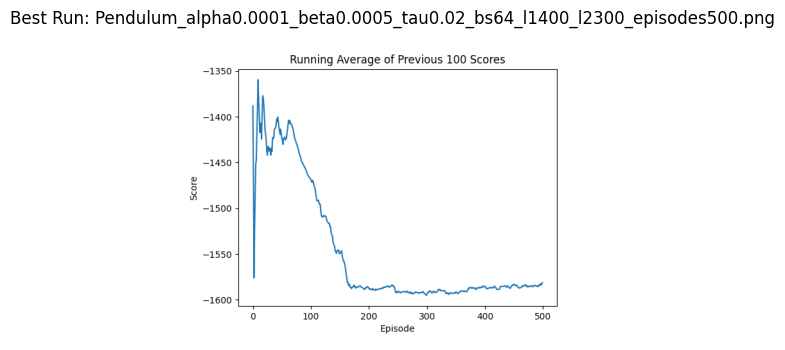

In [7]:
# Example: plot the best run
best_row = df.sort_values('best_score').iloc[0]
plot_file = best_row['plot_file'] if 'plot_file' in best_row else best_row['plot']
img_path = os.path.join('..', 'results', os.path.basename(plot_file))
img = plt.imread(img_path)
plt.figure(figsize=(8,4))
plt.imshow(img)
plt.axis('off')
plt.title(f"Best Run: {os.path.basename(plot_file)}")
plt.show()

## Generate Markdown Table for Best Runs
This cell generates a markdown table for the top 5 runs by best score.  
**Copy the output below and paste it into ANALYSIS.md.**

In [10]:
# Check available columns
print("Available columns:", df.columns.tolist())

# Use both possible hidden layer column names for flexibility
cols = ['alpha', 'beta', 'tau', 'batch_size', 'layer1', 'layer2', 'layer1_size', 'layer2_size', 'best_score', 'avg_score', 'plot_file']
cols = [c for c in cols if c in df.columns]

top5 = df.sort_values('best_score').head(5)
md = '| ' + ' | '.join(cols) + ' |\n'
md += '| ' + ' | '.join(['--------'] * len(cols)) + ' |\n'
for _, row in top5.iterrows():
    plot_link = f"[plot](../results/{os.path.basename(row['plot_file'])})" if 'plot_file' in row else ""
    row_vals = [str(row[c]) for c in cols if c != 'plot_file']
    if 'plot_file' in cols:
        row_vals.append(plot_link)
    md += '| ' + ' | '.join(row_vals) + ' |\n'
print(md)

Available columns: ['alpha', 'beta', 'tau', 'batch_size', 'layer1_size', 'layer2_size', 'best_score', 'avg_score', 'plot_file']
| alpha | beta | tau | batch_size | layer1_size | layer2_size | best_score | avg_score | plot_file |
| -------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- |
| 0.0001 | 0.0005 | 0.02 | 64 | 400 | 300 | -902.502449993761 | -1582.0322575638288 | [plot](../results/Pendulum_alpha0.0001_beta0.0005_tau0.02_bs64_l1400_l2300_episodes500.png) |
| 0.0001 | 0.0001 | 0.005 | 64 | 400 | 300 | -797.8417926253843 | -1396.4137215824437 | [plot](../results/Pendulum_alpha0.0001_beta0.0001_tau0.005_bs64_l1400_l2300_episodes500.png) |
| 0.001 | 0.0005 | 0.005 | 128 | 400 | 300 | -788.346390770206 | -1381.3180780803616 | [plot](../results/Pendulum_alpha0.001_beta0.0005_tau0.005_bs128_l1400_l2300_episodes500.png) |
| 0.0001 | 0.001 | 0.02 | 128 | 400 | 300 | -767.8487945823196 | -1580.757419423607 | [plot](../results/Pendulum_alpha0.0001_